## Question 1

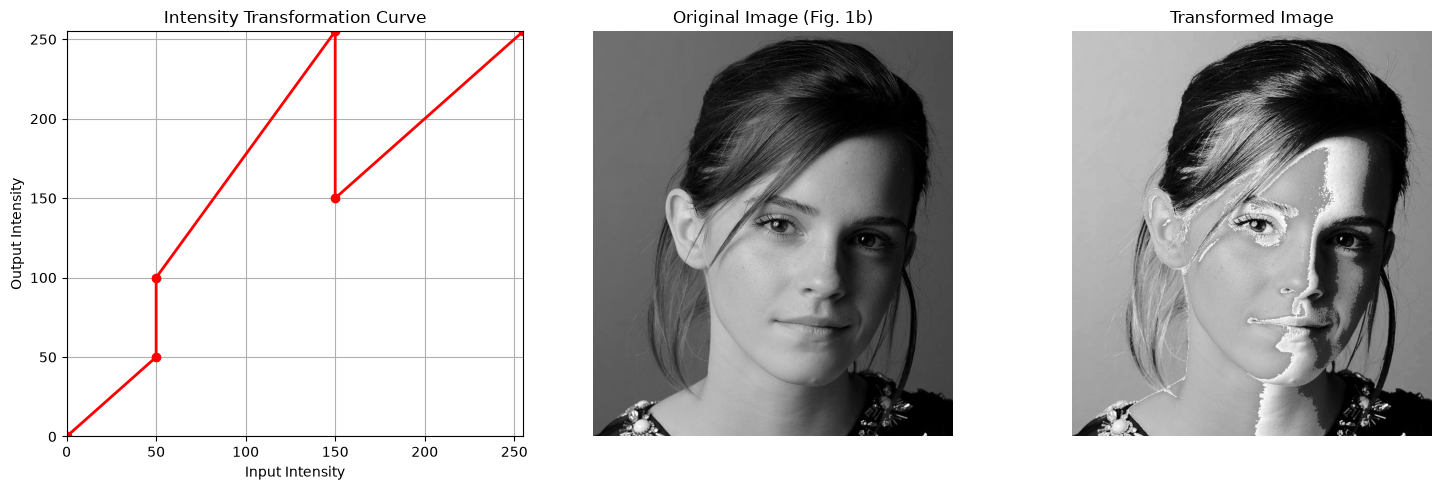

In [152]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
def intensity_transform(im, breakpoints):
    xp = breakpoints[:, 0]
    fp = breakpoints[:, 1]
    transformed_im = np.interp(im, xp, fp).astype(np.uint8)
    return transformed_im
im = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)
breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
])
transformed_im = intensity_transform(im, breakpoints)
fig = plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(breakpoints[:, 0], breakpoints[:, 1], 'r-o', linewidth=2, markersize=6)
plt.title('Intensity Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(True)
plt.subplot(1, 3, 2)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image (Fig. 1b)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(transformed_im, cmap='gray', vmin=0, vmax=255)
plt.title('Transformed Image')
plt.axis('off')
plt.tight_layout()
plt.show()

### After Experimenting with different break points

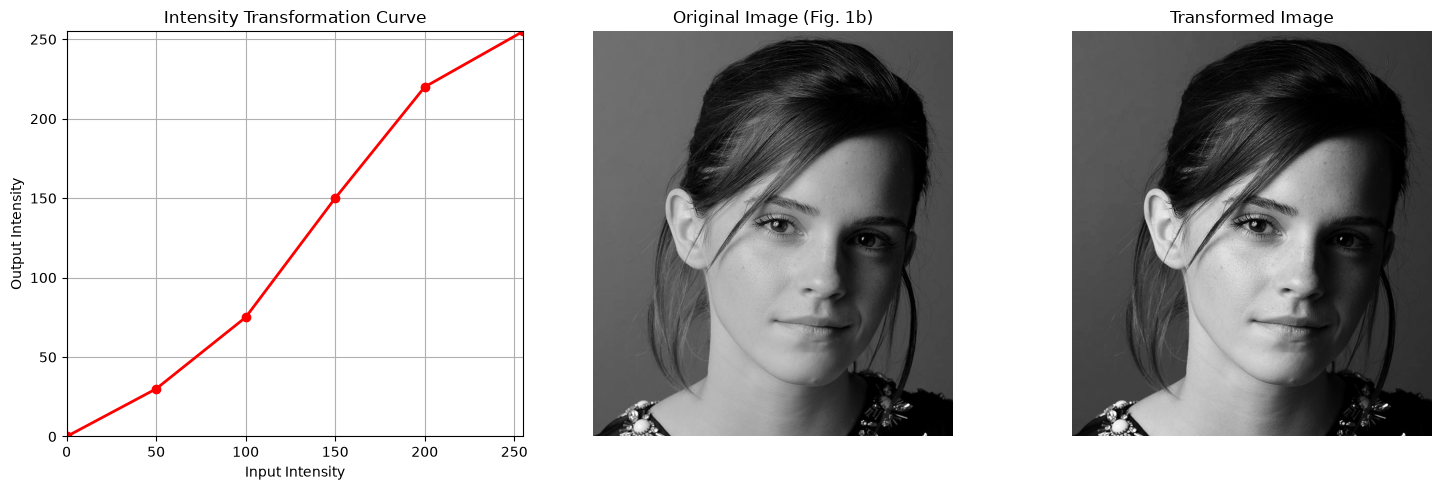

In [153]:
breakpoints = np.array([
    [0, 0],
    [50, 30],
    [100, 75],
    [150, 150],
    [200, 220],
    [255, 255]
])
transformed_im = intensity_transform(im, breakpoints)
fig = plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(breakpoints[:, 0], breakpoints[:, 1], 'r-o', linewidth=2, markersize=6)
plt.title('Intensity Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(True)
plt.subplot(1, 3, 2)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image (Fig. 1b)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(transformed_im, cmap='gray', vmin=0, vmax=255)
plt.title('Transformed Image')
plt.axis('off')
plt.tight_layout()
plt.show()

## Question 2

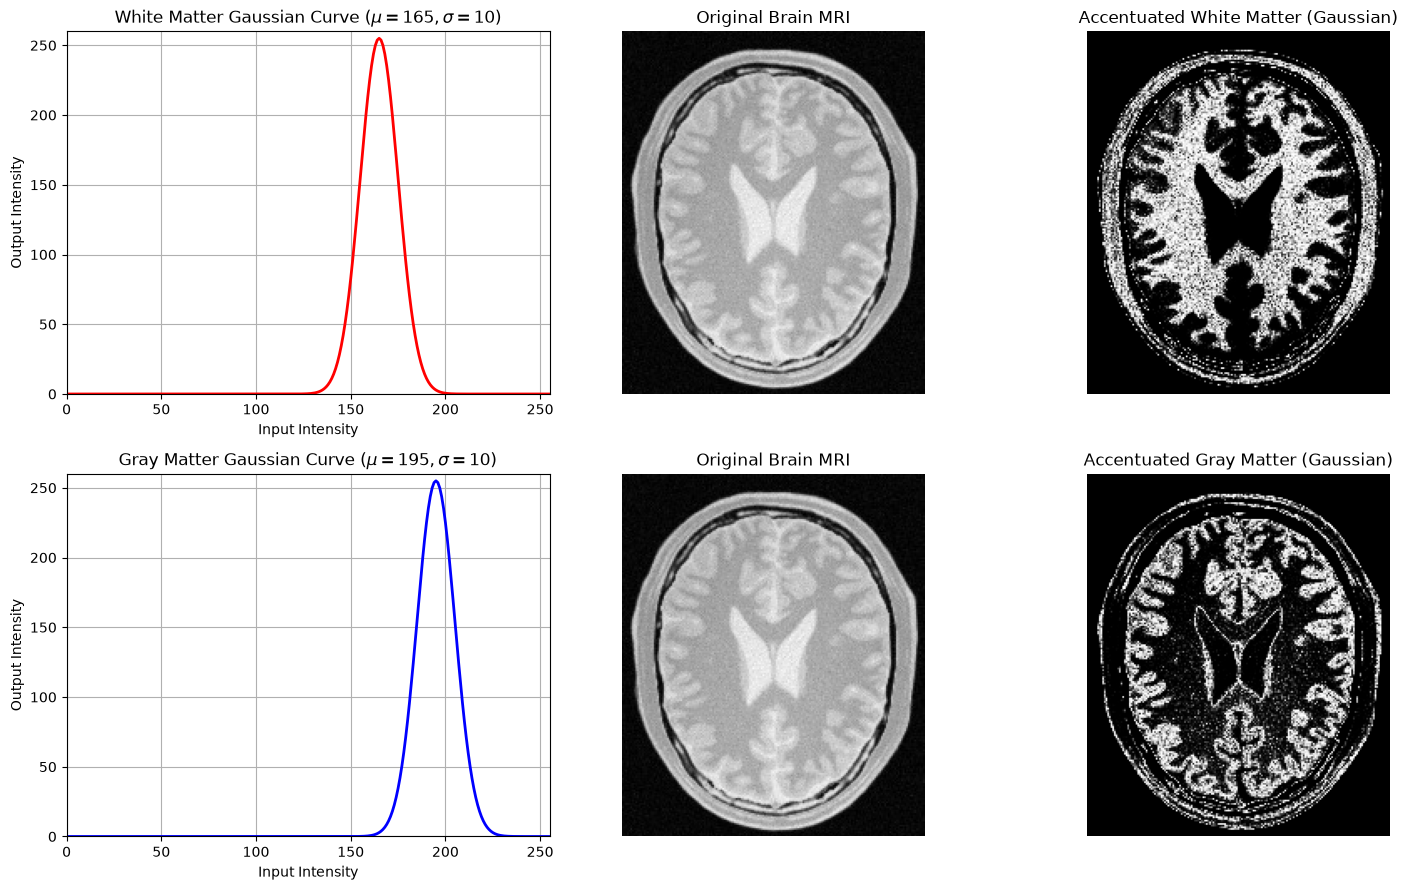

In [154]:
def gaussian_intensity_transform(im, mu, sigma):
    x = im.astype(np.float32)
    transformed = 255.0 * np.exp(-((x - mu)**2) / (2.0 * (sigma**2)))
    return np.clip(transformed, 0, 255).astype(np.uint8)
brain_im = cv.imread('images/q2.jpeg', cv.IMREAD_GRAYSCALE)
mu_wm, sigma_wm = 165.0, 10.0
wm_gaussian = gaussian_intensity_transform(brain_im, mu_wm, sigma_wm)
mu_gm, sigma_gm = 195.0, 10.0
gm_gaussian = gaussian_intensity_transform(brain_im, mu_gm, sigma_gm)
x_vals = np.arange(0, 256)
curve_wm = 255.0 * np.exp(-((x_vals - mu_wm)**2) / (2.0 * (sigma_wm**2)))
curve_gm = 255.0 * np.exp(-((x_vals - mu_gm)**2) / (2.0 * (sigma_gm**2)))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes[0, 0].plot(x_vals, curve_wm, 'r-', linewidth=2)
axes[0, 0].set_title(rf'White Matter Gaussian Curve ($\mu={int(mu_wm)}, \sigma={int(sigma_wm)}$)')
axes[0, 0].set_xlabel('Input Intensity'); axes[0, 0].set_ylabel('Output Intensity')
axes[0, 0].set_xlim([0, 255]); axes[0, 0].set_ylim([0, 260])
axes[0, 0].grid(True)
axes[0, 1].imshow(brain_im, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Original Brain MRI')
axes[0, 1].axis('off')
axes[0, 2].imshow(wm_gaussian, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('Accentuated White Matter (Gaussian)')
axes[0, 2].axis('off')
axes[1, 0].plot(x_vals, curve_gm, 'b-', linewidth=2)
axes[1, 0].set_title(rf'Gray Matter Gaussian Curve ($\mu={int(mu_gm)}, \sigma={int(sigma_gm)}$)')
axes[1, 0].set_xlabel('Input Intensity'); axes[1, 0].set_ylabel('Output Intensity')
axes[1, 0].set_xlim([0, 255]); axes[1, 0].set_ylim([0, 260])
axes[1, 0].grid(True)
axes[1, 1].imshow(brain_im, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Original Brain MRI')
axes[1, 1].axis('off')
axes[1, 2].imshow(gm_gaussian, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title('Accentuated Gray Matter (Gaussian)')
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

## Question 3

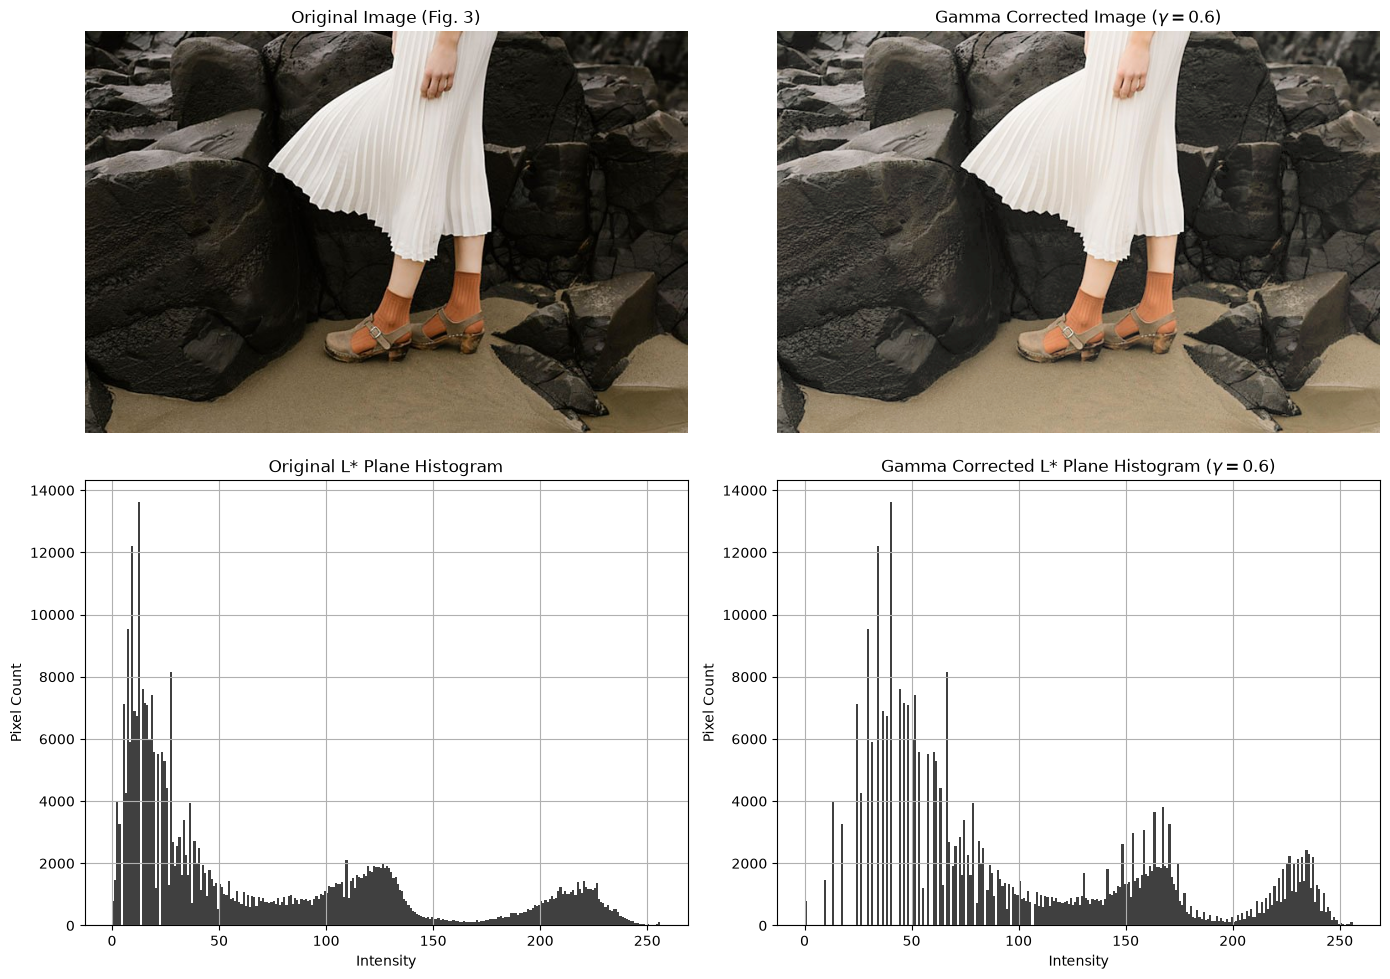

Stated Gamma Value: gamma = 0.6


In [155]:
img_bgr = cv.imread('images/fig3.jpeg')
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)
L_plane, a_plane, b_plane = cv.split(img_lab)
gamma = 0.6
L_normalized = L_plane.astype(np.float32) / 255.0
L_corrected_norm = np.power(L_normalized, gamma)
L_corrected = np.clip(L_corrected_norm * 255.0, 0, 255).astype(np.uint8)
lab_corrected = cv.merge([L_corrected, a_plane, b_plane])
img_corrected_bgr = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
img_rgb_orig = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_rgb_corr = cv.cvtColor(img_corrected_bgr, cv.COLOR_BGR2RGB)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(img_rgb_orig)
axes[0, 0].set_title("Original Image (Fig. 3)")
axes[0, 0].axis('off')
axes[0, 1].imshow(img_rgb_corr)
axes[0, 1].set_title(rf"Gamma Corrected Image ($\gamma = {gamma}$)")
axes[0, 1].axis('off')
axes[1, 0].hist(L_plane.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
axes[1, 0].set_title("Original L* Plane Histogram")
axes[1, 0].set_xlabel("Intensity")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].grid(True)
axes[1, 1].hist(L_corrected.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
axes[1, 1].set_title(rf"Gamma Corrected L* Plane Histogram ($\gamma = {gamma}$)")
axes[1, 1].set_xlabel("Intensity")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].grid(True)
plt.tight_layout()
plt.show()
print(f"Stated Gamma Value: gamma = {gamma}")

## Question 4

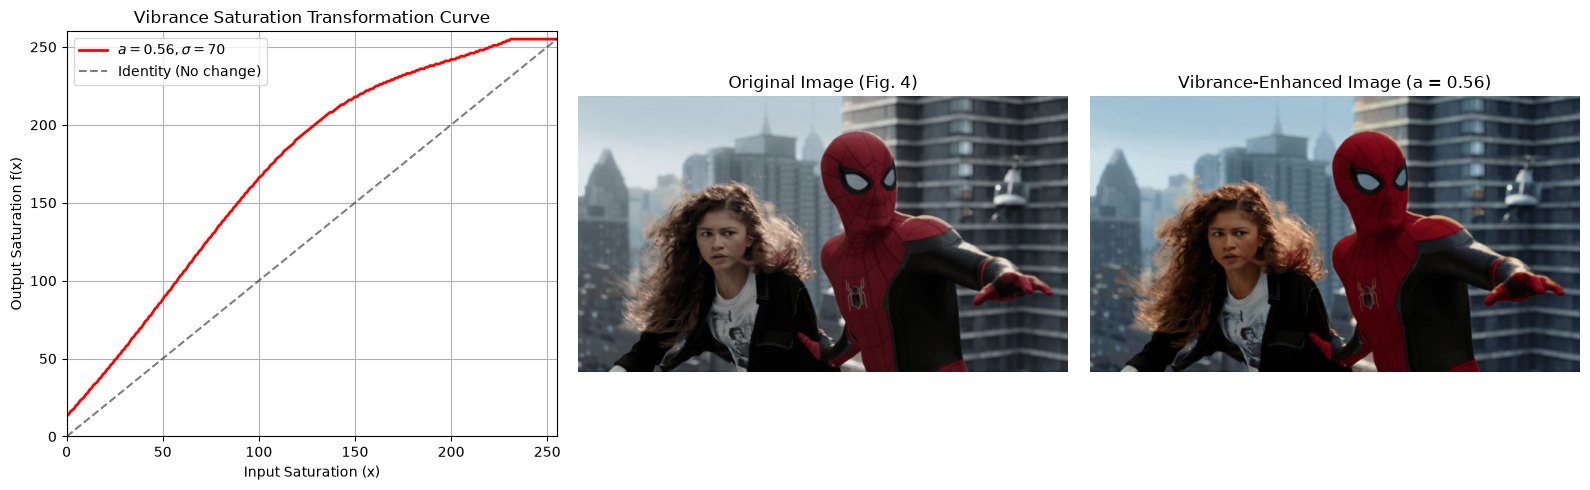

Reported value of a: 0.56


In [156]:
def vibrance_transform(x, a, sigma=70.0):
    x_float = x.astype(np.float32)
    boost = a * 128.0 * np.exp(-((x_float - 128.0)**2) / (2.0 * (sigma**2)))
    transformed = np.minimum(x_float + boost, 255.0)
    return transformed.astype(np.uint8)
img_bgr = cv.imread('images/fig4.jpeg')
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
H, S, V = cv.split(img_hsv)
a_value = 0.56
sigma_value = 70.0
S_enhanced = vibrance_transform(S, a=a_value, sigma=sigma_value)
hsv_enhanced = cv.merge([H, S_enhanced, V])
img_enhanced_bgr = cv.cvtColor(hsv_enhanced, cv.COLOR_HSV2BGR)
img_orig_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_enhanced_rgb = cv.cvtColor(img_enhanced_bgr, cv.COLOR_BGR2RGB)
fig = plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
x_vals = np.arange(0, 256, dtype=np.float32)
y_vals = vibrance_transform(x_vals, a=a_value, sigma=sigma_value)
plt.plot(x_vals, y_vals, 'r-', linewidth=2, label=rf'$a = {a_value}, \sigma = {int(sigma_value)}$')
plt.plot([0, 255], [0, 255], 'k--', alpha=0.5, label='Identity (No change)')
plt.title('Vibrance Saturation Transformation Curve')
plt.xlabel('Input Saturation (x)')
plt.ylabel('Output Saturation f(x)')
plt.xlim([0, 255]); plt.ylim([0, 260])
plt.legend(); plt.grid(True)
plt.subplot(1, 3, 2)
plt.imshow(img_orig_rgb)
plt.title('Original Image (Fig. 4)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(img_enhanced_rgb)
plt.title(f'Vibrance-Enhanced Image (a = {a_value})')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Reported value of a: {a_value}")

## Question 5

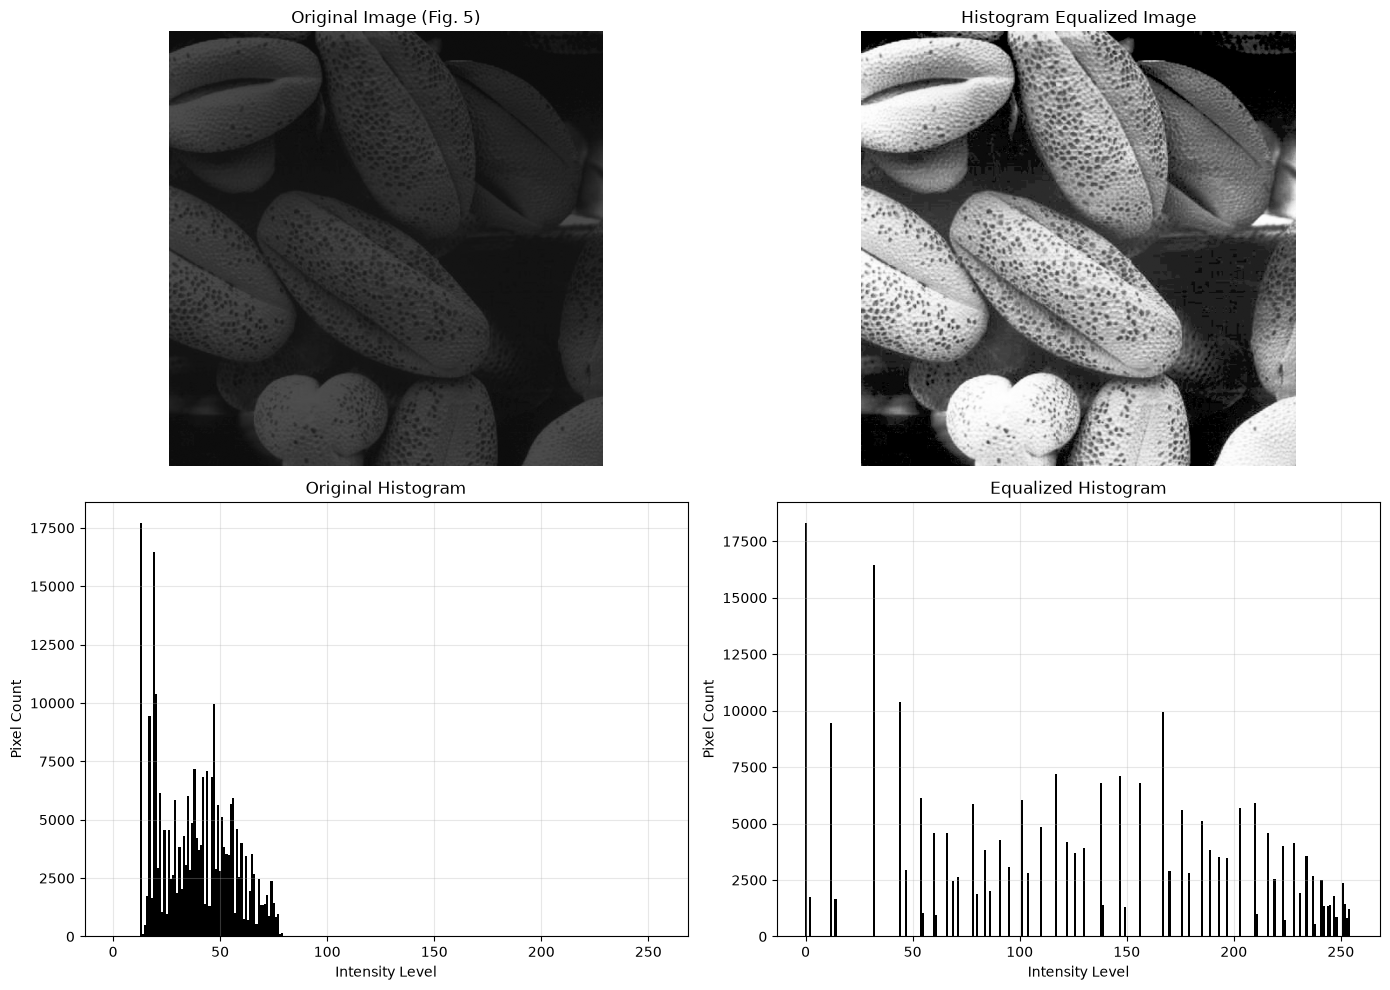

In [157]:
def custom_histogram_equalization(im):
    hist, _ = np.histogram(im.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_normalized = (cdf_masked - cdf_masked.min()) * 255.0 / (cdf_masked.max() - cdf_masked.min())
    lut = np.ma.filled(cdf_normalized, 0).astype(np.uint8)
    im_equalized = lut[im]
    return im_equalized, hist, lut
img_orig = cv.imread('images/shells.tif', cv.IMREAD_GRAYSCALE)
img_eq, hist_orig, lut = custom_histogram_equalization(img_orig)
hist_eq, _ = np.histogram(img_eq.flatten(), 256, [0, 256])
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Original Image (Fig. 5)")
axes[0, 0].axis('off')
axes[0, 1].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title("Histogram Equalized Image")
axes[0, 1].axis('off')
axes[1, 0].bar(range(256), hist_orig, color='black', width=1.0)
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlabel("Intensity Level")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 1].bar(range(256), hist_eq, color='black', width=1.0)
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlabel("Intensity Level")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()